This file graphs the holes at eps 10, 15, 20 for the parks data and creates a final data frame called "holes_no_parks.geojson" which contains the holes **excluding** the parks themselves (sometimes a park would be considered a hole because of how the points/grid centroids get mapped to the park boundary)

In [1]:
#import packages
import geopandas as gpd
import pandas as pd 
import osmnx as ox

In [ ]:
#reading in the holes, isochrones, and parks
holes = gpd.read_file('Grid_Intersection_Centroids/walk_holes.geojson')
isochrones = gpd.read_file('Grid_Intersection_Centroids/grid_intersect_centroids/isochrones_walk/isochrone_full_walk.geojson')
parks  = gpd.read_file('Parks_(2024).geojson')

#grabbing Dallas County from osm
place = "Dallas County, Texas, United States of America"
api = ox.geocoder.geocode_to_gdf(place)
dallas_geo = api['geometry'].iloc[0]

In [58]:
#grabbing only the parks in dallas county
parks["in_dallas"] = parks.intersects(dallas_geo)
parks_in_dallas = parks[parks["in_dallas"] == True]

In [59]:
#creating a single Multipolygon for all parks
all_parks = parks_in_dallas.union_all()

In [81]:
parks_gdf = gpd.GeoDataFrame({'geometry': [all_parks]}, crs = 'EPSG:4326')

<Axes: >

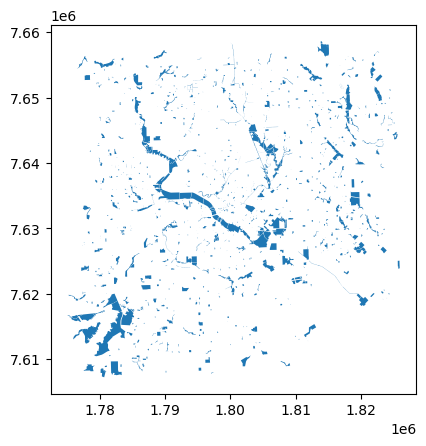

In [85]:
parks_gdf = parks_gdf.to_crs('EPSG:3083')

In [2]:
#seperating the 10, 15, 20 eps holes for plotting
holes_10  = holes.iloc[[0]]
holes_15 = holes.iloc[[1]].reset_index()
holes_20 = holes.iloc[[2]].reset_index()

NameError: name 'holes' is not defined

<Axes: >

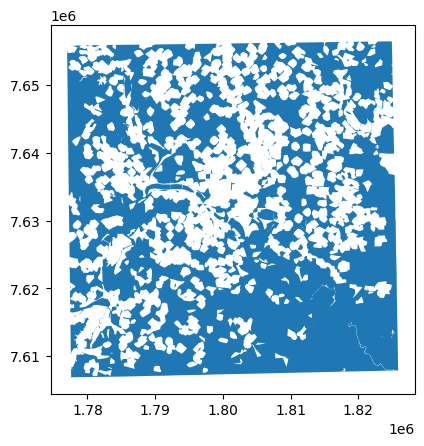

In [108]:
holes_10.plot()

In [160]:
dallas_county_gdf = api[['geometry']].to_crs('EPSG:3083')
inverse_10 = dallas_county_gdf.difference(holes_10_diff)
inverse_15 = dallas_county_gdf.difference(holes_15_diff)
inverse_20 = dallas_county_gdf.difference(holes_20_diff)

In [3]:
inverse_20.plot()
#now the blue area is what is COVERED

NameError: name 'inverse_20' is not defined

In [4]:
#subrtracting the parks themselves from the regions considered holes
print(holes_10.crs)
print(holes_15.crs)
print(holes_20.crs)
print(parks_gdf.crs)

holes_10_diff = holes_10.difference(parks_gdf)
holes_15_diff = holes_15.difference(parks_gdf)
holes_20_diff = holes_20.difference(parks_gdf)

NameError: name 'holes_10' is not defined

<Axes: >

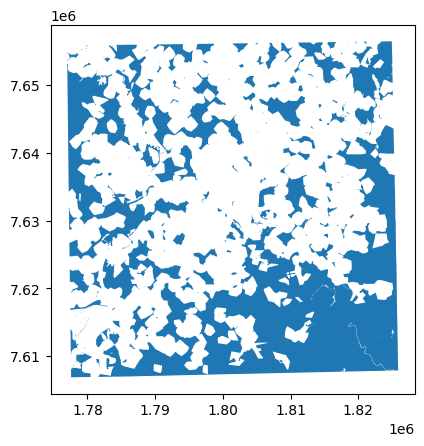

In [115]:
holes_15_diff.plot()

<Axes: >

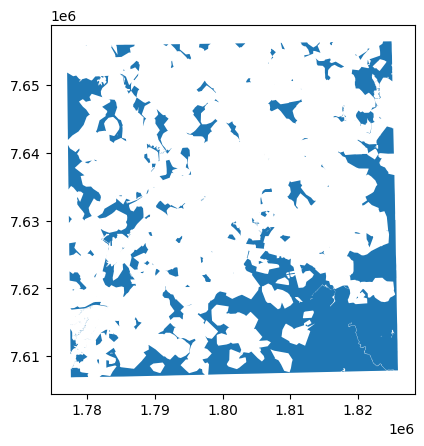

In [116]:
holes_20_diff.plot()

In [ ]:
#creating a data frame that includes geometry for the holes and for the covereage areas at each eps
holes_no_parks = gpd.GeoDataFrame({'eps': [10, 15, 20], 'holes': [holes_10_diff.iloc[0], holes_15_diff.iloc[0], holes_20_diff.iloc[0]], 'coverage': [inverse_10.iloc[0], inverse_15.iloc[0], inverse_20.iloc[0]]}, geometry = 'coverage', crs = 'EPSG: 3083')

#saving
holes_no_parks.to_file('holes_no_parks.geojson', driver = 'GEOJSON')